# Automatic Feature selection techniques

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/tutorials/nb_automatic_best_num_features.ipynb)

Below we'll walk you through how to change selecting the best `feature_set` manually to automatically by using `get_reduced_features_set`. This function has many ways of selecting the most optimal feature selection for your use-case. Let's show you first how a simple 'manaul' probatus feature elimination works before we'll show you how to automate it.

In [1]:
%%capture
!pip install probatus
!pip install xgboost

In [2]:
from probatus.features import ShapRFECV
from sklearn.datasets import make_classification
from xgboost import XGBClassifier

### Basic example of ShapRFECV

In [3]:
# Simple ShapRFECV example
X, y = make_classification(n_samples=500, n_informative=20, n_features=50)
model = XGBClassifier(n_estimators=100)
shap_elimination = ShapRFECV(model, step=0.2, min_features_to_select=5, cv=5, scoring="f1")
report = shap_elimination.fit_compute(X, y)

Feature Elimination:   0%|          | 0/45 [00:00<?, ?it/s]

In [4]:
# Inspect the report generated by ShapRFECV
# Can you find the best iteration? Look at `train_metric_mean`.
report

,num_features,features_set,eliminated_features,train_metric_mean,train_metric_std,val_metric_mean,val_metric_std
1,50,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[37, 34, 30, 49, 4, 15, 1, 21, 25, 42]",1.0,0.0,0.825134,0.039196
2,40,"[0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[6, 35, 27, 36, 5, 10, 31, 11]",1.0,0.0,0.809123,0.041250
3,32,"[0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 18, 19,...","[26, 32, 39, 41, 44, 48]",1.0,0.0,0.835474,0.019248
4,26,"[0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 18, 19,...","[18, 38, 22, 45, 33]",1.0,0.0,0.852823,0.016192
5,21,"[0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 19, 20,...","[29, 28, 7, 9]",1.0,0.0,0.846827,0.011337
6,17,"[0, 2, 3, 8, 12, 13, 14, 16, 17, 19, 20, 23, 2...","[13, 46, 23]",1.0,0.0,0.851856,0.029462
7,14,"[0, 2, 3, 8, 12, 14, 16, 17, 19, 20, 24, 40, 4...","[8, 43]",1.0,0.0,0.847922,0.035090
8,12,"[0, 2, 3, 12, 14, 16, 17, 19, 20, 24, 40, 47]","[16, 40]",1.0,0.0,0.835737,0.023805
9,10,"[0, 2, 3, 12, 14, 17, 19, 20, 24, 47]","[19, 20]",1.0,0.0,0.809134,0.028836
10,8,"[0, 2, 3, 12, 14, 17, 24, 47]",[0],1.0,0.0,0.776044,0.032105


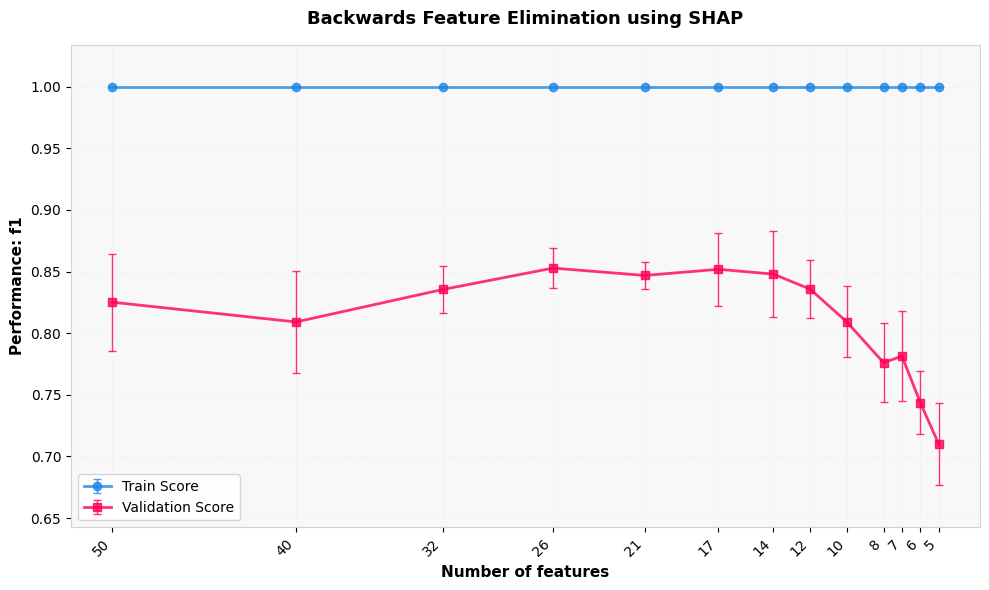

In [5]:
# We can visually inspect the report and try identify the best iteration
shap_elimination.plot()

In [6]:
# Once we have identified which iteration was best, we can get the feature names by:
shap_elimination.get_reduced_features_set(num_features=21)

[0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 19, 20, 23, 24, 28, 29, 40, 43, 46, 47]

# But, is there a more automated way of selecting "best" features?

Yes, probatus support a few strategies for selecting the best `num_features` for your needs.

Before we jump into these automated techniques, there are a number of factors you might want to consider when selecting the best iteration:
1. **Model performance score:** Most people will care about this the most. You'll try to maximize a score like f1 or accuracy or ROC_AUC. But there are more factors to consider...
2. **Variance of model performance:** If your model performance scores vary considerably across cross validation folds, it might be a sign that your model is not generalizing well. Some people may want to ensure model performance standard deviation is also minimized.
3. **Number of features:** You might want to keep the number of features to a minimum (smaller model, siplier data pipeline, easier to explain model)

To accomodate some of the above needs, probatus supports automated strategies to select the best "num_features". Strategies supported are:
1. **num_features="best":** If what you care about is maximizing `val_metric_mean` (model performance score), this strategy is for you.
2. **num_features="best_coherent":** If you care about high model performance whilst also minimizing variation of model performance between cross validation folds, this strategy is for you.
3. **num_features="best_parsimonious":** If you care about high model performance whilst also minimizing the number of features selected, this model is for you.

In [7]:
# Best
best_features = shap_elimination.get_reduced_features_set(num_features="best")
print(f"The {len(best_features)} best features are: {best_features}")

The 26 best features are: [0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 28, 29, 33, 38, 40, 43, 45, 46, 47]


In [8]:
# Best coherent
best_features = shap_elimination.get_reduced_features_set(num_features="best_coherent")
print(f"The {len(best_features)} best coherent features are: {best_features}")

The 21 best coherent features are: [0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 19, 20, 23, 24, 28, 29, 40, 43, 46, 47]


In [9]:
# Best parsimonious
best_features = shap_elimination.get_reduced_features_set(num_features="best_parsimonious")
print(f"The {len(best_features)} best parsimonious features are: {best_features}")

The 5 best parsimonious features are: [3, 12, 14, 17, 47]


In [10]:
# Note, you can change the behavior of `best_coherent` and `best_parsimonious` by changing the `standard_error_threshold` parameter
# Best coherent (standard_error_threshold=0.5)
best_features = shap_elimination.get_reduced_features_set(
    num_features="best_parsimonious", standard_error_threshold=0.5
)
print(f"The {len(best_features)} best coherent features are: {best_features}")

The 5 best coherent features are: [3, 12, 14, 17, 47]


# Support & Ranking
In alignment with the sklearn implementation of RFECV, you can get `support` and `ranking` output from ShapRFECV. 

In [11]:
# Get support (boolean mask of X feature columns)
best_features = shap_elimination.get_reduced_features_set(num_features="best", return_type="feature_names")
best_features_support = shap_elimination.get_reduced_features_set(num_features="best", return_type="support")
best_features_ranking = shap_elimination.get_reduced_features_set(num_features="best", return_type="ranking")
print(f"The {len(best_features)} best features are: {best_features}")
print(f"Support boolean mask: {best_features_support}")
print(f"Ranking: {best_features_ranking}")

The 26 best features are: [0, 2, 3, 7, 8, 9, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 28, 29, 33, 38, 40, 43, 45, 46, 47]
Support boolean mask: [True, False, True, True, False, False, False, True, True, True, False, False, True, True, True, False, True, True, True, True, True, False, True, True, True, False, False, False, True, True, False, False, False, True, False, False, False, False, True, False, True, False, False, True, False, True, True, True, False, False]
Ranking: [3, 42, 1, 0, 40, 32, 28, 15, 8, 16, 33, 35, 0, 10, 0, 41, 6, 0, 17, 4, 5, 43, 19, 12, 2, 44, 22, 30, 14, 13, 38, 34, 23, 21, 37, 29, 31, 36, 18, 24, 7, 25, 45, 9, 26, 20, 11, 0, 27, 39]
